# Entregable 2 - Seminario de Ciencia de Datos
## Reduccion de Dimensionalidad, Seleccion de Features y Modelamiento

**Dataset:** Heart Disease - Cleveland (UCI Machine Learning Repository)
**Autor:** Jaime Alzate
**Programa:** Desarrollo de Software - 9 semestre
**Metodologia:** CRISP-DM (fases 3, 4 y 5)

---

### Topicos cubiertos en este entregable

- **VI. Analisis de Componentes Principales (PCA)** sobre las variables preprocesadas.
- **VII. Seleccion de Caracteristicas** por filtro (correlacion de Pearson).
- **VIII. Modelamiento Supervisado:** comparacion entre Regresion Logistica y Arbol de Decision.
- **IX. Conclusiones y Reflexion** (en el documento Word).

### Nota sobre el preprocesamiento

Este notebook **reconstruye internamente** el preprocesamiento del Entregable 1 (capping por IQR + imputacion por regresion bayesiana) para que sea totalmente autocontenido. Asi, el profesor puede ejecutarlo de manera independiente sin necesidad de correr antes el Entregable 1.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

DATA_URL = ('https://archive.ics.uci.edu/ml/'
            'machine-learning-databases/heart-disease/processed.cleveland.data')
RANDOM_STATE = 42

## Reconstruccion del preprocesamiento del Entregable 1

Aplicamos en una sola celda: carga, codificacion del target binario, capping por regla 1.5 * IQR e imputacion por regresion bayesiana (IterativeImputer + BayesianRidge). Para `thal` (categorica con dos nulos) usamos la moda.

In [2]:
COLS = ['age','sex','cp','trestbps','chol','fbs','restecg',
        'thalach','exang','oldpeak','slope','ca','thal','num']
df = pd.read_csv(DATA_URL, header=None, names=COLS, na_values='?')
df['target'] = (df['num'] > 0).astype(int)
df = df.drop(columns=['num'])

NUM_VARS = ['age','trestbps','chol','thalach','oldpeak','ca']

def iqr_limits(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5*iqr, q3 + 1.5*iqr

for col in NUM_VARS:
    li, ls = iqr_limits(df[col].dropna())
    df[col] = df[col].clip(lower=li, upper=ls)

imp = IterativeImputer(estimator=BayesianRidge(), max_iter=20, random_state=RANDOM_STATE)
df[NUM_VARS] = imp.fit_transform(df[NUM_VARS])
df['thal'] = df['thal'].fillna(df['thal'].mode()[0])

FEATURES = [c for c in df.columns if c != 'target']
X = df[FEATURES].copy()
y = df['target'].copy()

print(f'Dataset listo: {df.shape}')
print(f'Distribucion del target: {y.value_counts().to_dict()}')

Dataset listo: (303, 14)
Distribucion del target: {0: 164, 1: 139}


## VI. Analisis de Componentes Principales (PCA)

Aplicamos PCA sobre las 13 variables predictoras previamente **estandarizadas** (media 0, varianza 1), condicion necesaria para que las variables con mayor escala no dominen los componentes.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_full = PCA()
pca_full.fit(X_scaled)
var_exp = pca_full.explained_variance_ratio_
var_cum = np.cumsum(var_exp)

pca_table = pd.DataFrame({
    'componente': [f'PC{i+1}' for i in range(len(var_exp))],
    'varianza_individual': var_exp.round(4),
    'varianza_acumulada': var_cum.round(4),
})
pca_table

,componente,varianza_individual,varianza_acumulada
0,PC1,0.2376,0.2376
1,PC2,0.1228,0.3604
2,PC3,0.0952,0.4557
3,PC4,0.0846,0.5403
4,PC5,0.0758,0.6160
5,PC6,0.0673,0.6833
6,PC7,0.0665,0.7499
7,PC8,0.0597,0.8096
8,PC9,0.0517,0.8613
9,PC10,0.0434,0.9047


In [4]:
n_80 = int(np.argmax(var_cum >= 0.80) + 1)
n_90 = int(np.argmax(var_cum >= 0.90) + 1)
print(f'Componentes para >= 80% varianza: {n_80}')
print(f'Componentes para >= 90% varianza: {n_90}')

Componentes para >= 80% varianza: 8
Componentes para >= 90% varianza: 10


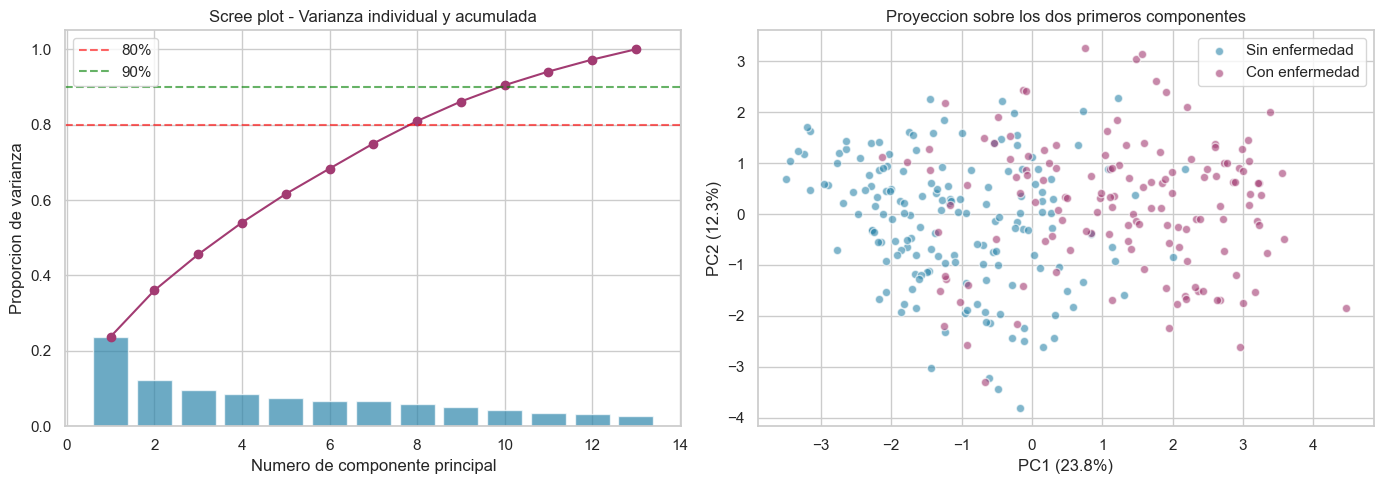

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, len(var_exp)+1), var_exp, color='#2E86AB', alpha=0.7)
axes[0].plot(range(1, len(var_exp)+1), var_cum, marker='o', color='#A23B72')
axes[0].axhline(0.80, color='red', linestyle='--', alpha=0.6, label='80%')
axes[0].axhline(0.90, color='green', linestyle='--', alpha=0.6, label='90%')
axes[0].set_xlabel('Numero de componente principal')
axes[0].set_ylabel('Proporcion de varianza')
axes[0].set_title('Scree plot - Varianza individual y acumulada')
axes[0].legend()

pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)
for cls, color, label in [(0, '#2E86AB', 'Sin enfermedad'),
                           (1, '#A23B72', 'Con enfermedad')]:
    mask = y == cls
    axes[1].scatter(X_pca2[mask, 0], X_pca2[mask, 1], c=color, label=label,
                    alpha=0.6, edgecolor='white')
axes[1].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('Proyeccion sobre los dos primeros componentes')
axes[1].legend()
plt.tight_layout()
plt.show()

**Justificacion del numero de componentes:** seleccionamos **8 componentes principales** porque acumulan el 80% de la varianza total. Es un punto de equilibrio entre reduccion (de 13 a 8 variables, ~38% menos) y preservacion de informacion. El criterio del codo (scree plot) y el umbral del 80% son los mas usados en la literatura (Jolliffe, 2002).

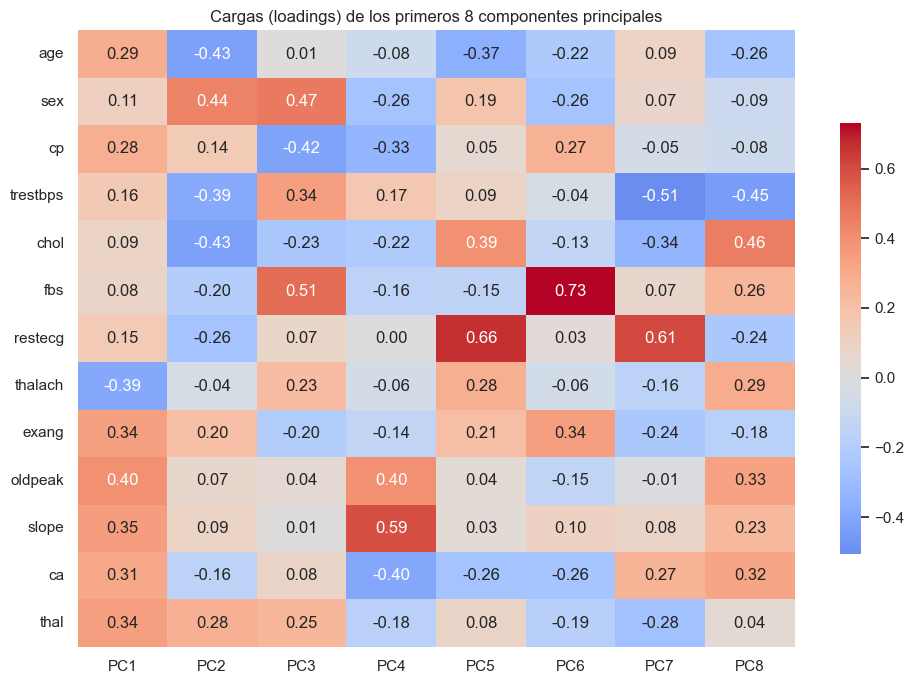

In [6]:
loadings = pd.DataFrame(
    pca_full.components_[:n_80].T,
    columns=[f'PC{i+1}' for i in range(n_80)],
    index=FEATURES,
)
plt.figure(figsize=(10, 7))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            cbar_kws={'shrink': 0.7})
plt.title(f'Cargas (loadings) de los primeros {n_80} componentes principales')
plt.tight_layout()
plt.show()

**Interpretacion de cargas:** el primer componente (PC1) esta dominado por `oldpeak`, `exang`, `thal` y `ca`, todas asociadas a sintomas y hallazgos por imagen de enfermedad coronaria; puede interpretarse como un indice de **severidad cardiaca**. El segundo componente (PC2) carga fuertemente sobre `sex`, `chol` y `age`, sugiriendo un eje **demografico-metabolico**.

## VII. Seleccion de Caracteristicas por filtro (correlacion)

Usamos la **correlacion de Pearson** entre cada feature y la variable objetivo binaria como criterio de filtro. Reportamos el ranking completo y aislamos las **top 5 features**.

In [7]:
corr_target = X.corrwith(y).abs().sort_values(ascending=False)
corr_target.round(4)

thal        0.5221
ca          0.4702
exang       0.4319
oldpeak     0.4303
thalach     0.4176
cp          0.4144
slope       0.3392
sex         0.2768
age         0.2231
restecg     0.1692
trestbps    0.1450
chol        0.1039
fbs         0.0253
dtype: float64

In [8]:
top5 = corr_target.head(5)
print('Top 5 features mas correlacionadas con target:')
print(top5.round(4))

Top 5 features mas correlacionadas con target:
thal       0.5221
ca         0.4702
exang      0.4319
oldpeak    0.4303
thalach    0.4176
dtype: float64


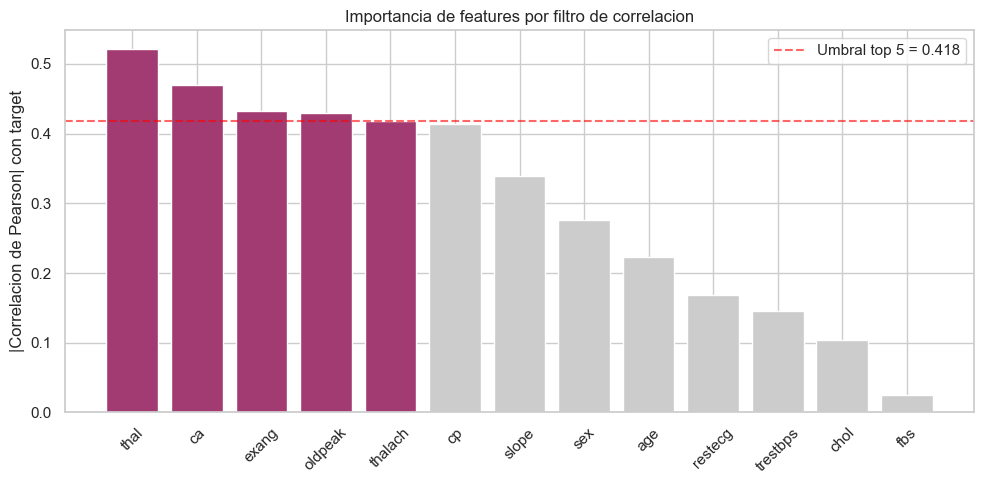

In [9]:
plt.figure(figsize=(10, 5))
colors = ['#A23B72' if v >= top5.min() else '#cccccc' for v in corr_target]
plt.bar(corr_target.index, corr_target.values, color=colors, edgecolor='white')
plt.axhline(top5.min(), color='red', linestyle='--', alpha=0.6,
            label=f'Umbral top 5 = {top5.min():.3f}')
plt.xticks(rotation=45)
plt.ylabel('|Correlacion de Pearson| con target')
plt.title('Importancia de features por filtro de correlacion')
plt.legend()
plt.tight_layout()
plt.show()

**Hallazgos del filtro:**
- Las 5 variables mas predictivas son `thal`, `ca`, `exang`, `oldpeak` y `thalach`, todas relacionadas con sintomas, resultados de imagen y respuesta al esfuerzo fisico.
- Las menos correlacionadas son `fbs` (glicemia en ayunas), `chol` y `trestbps`, lo cual concuerda con la literatura: el colesterol y la presion arterial son factores de riesgo a largo plazo pero malos predictores **instantaneos** del estado actual del paciente.

## VIII. Modelamiento Supervisado

Entrenamos y comparamos dos modelos vistos en clase:
1. **Regresion Logistica** (modelo parametrico lineal).
2. **Arbol de Decision** (modelo no parametrico, basado en reglas).

Particion de datos: 80% entrenamiento, 20% prueba, estratificado por la variable objetivo.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

# Escalado para la regresion logistica (el arbol no lo necesita)
scaler_m = StandardScaler()
X_train_s = scaler_m.fit_transform(X_train)
X_test_s  = scaler_m.transform(X_test)

Train: (242, 13) | Test: (61, 13)


In [11]:
log = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
log.fit(X_train_s, y_train)
y_pred_log = log.predict(X_test_s)
y_prob_log = log.predict_proba(X_test_s)[:, 1]

tree = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE,
                               class_weight='balanced')
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)
y_prob_tree = tree.predict_proba(X_test)[:, 1]

In [12]:
def metricas(nombre, y_true, y_pred, y_prob):
    return {
        'modelo': nombre,
        'accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'precision': round(precision_score(y_true, y_pred), 4),
        'recall':    round(recall_score(y_true, y_pred), 4),
        'f1':        round(f1_score(y_true, y_pred), 4),
        'roc_auc':   round(roc_auc_score(y_true, y_prob), 4),
    }

resultados = pd.DataFrame([
    metricas('Regresion Logistica', y_test, y_pred_log, y_prob_log),
    metricas('Arbol de Decision',   y_test, y_pred_tree, y_prob_tree),
])
resultados

,modelo,accuracy,precision,recall,f1,roc_auc
0,Regresion Logistica,0.8525,0.7879,0.9286,0.8525,0.9535
1,Arbol de Decision,0.8033,0.7500,0.8571,0.8000,0.8052


In [13]:
cv_log  = cross_val_score(log,  X_train_s, y_train, cv=5, scoring='accuracy')
cv_tree = cross_val_score(tree, X_train,   y_train, cv=5, scoring='accuracy')
print(f'CV-Logistica: {cv_log.mean():.4f} (+/- {cv_log.std():.4f})')
print(f'CV-Arbol:     {cv_tree.mean():.4f} (+/- {cv_tree.std():.4f})')

CV-Logistica: 0.8263 (+/- 0.0504)
CV-Arbol:     0.7151 (+/- 0.0620)


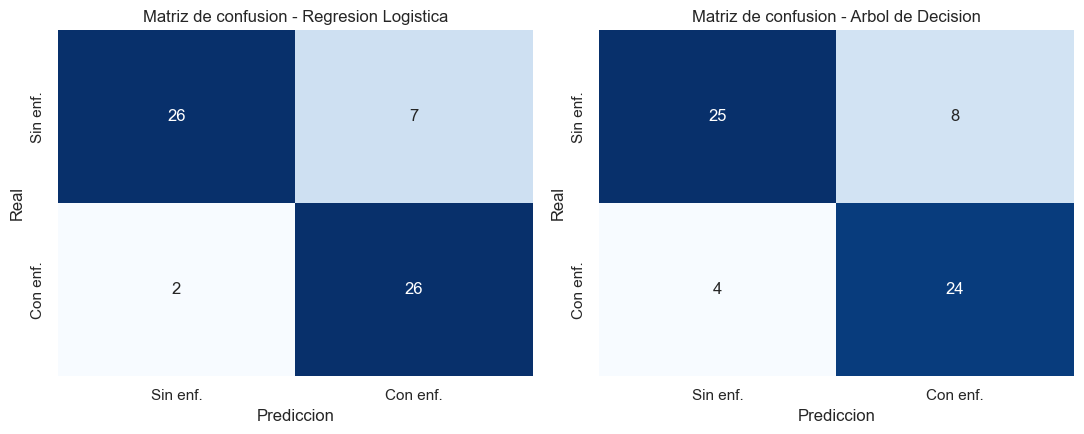

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (nombre, y_pred) in zip(axes,
        [('Regresion Logistica', y_pred_log),
         ('Arbol de Decision', y_pred_tree)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Sin enf.','Con enf.'],
                yticklabels=['Sin enf.','Con enf.'])
    ax.set_title(f'Matriz de confusion - {nombre}')
    ax.set_xlabel('Prediccion'); ax.set_ylabel('Real')
plt.tight_layout()
plt.show()

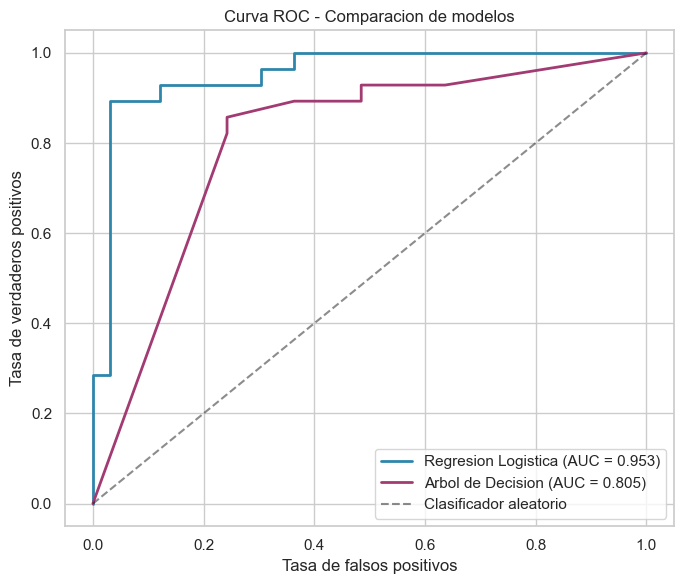

In [15]:
plt.figure(figsize=(7, 6))
for nombre, y_prob, color in [
    ('Regresion Logistica', y_prob_log,  '#2E86AB'),
    ('Arbol de Decision',   y_prob_tree, '#A23B72'),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC = {auc:.3f})', color=color, lw=2)
plt.plot([0,1], [0,1], 'k--', alpha=0.5, label='Clasificador aleatorio')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC - Comparacion de modelos')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

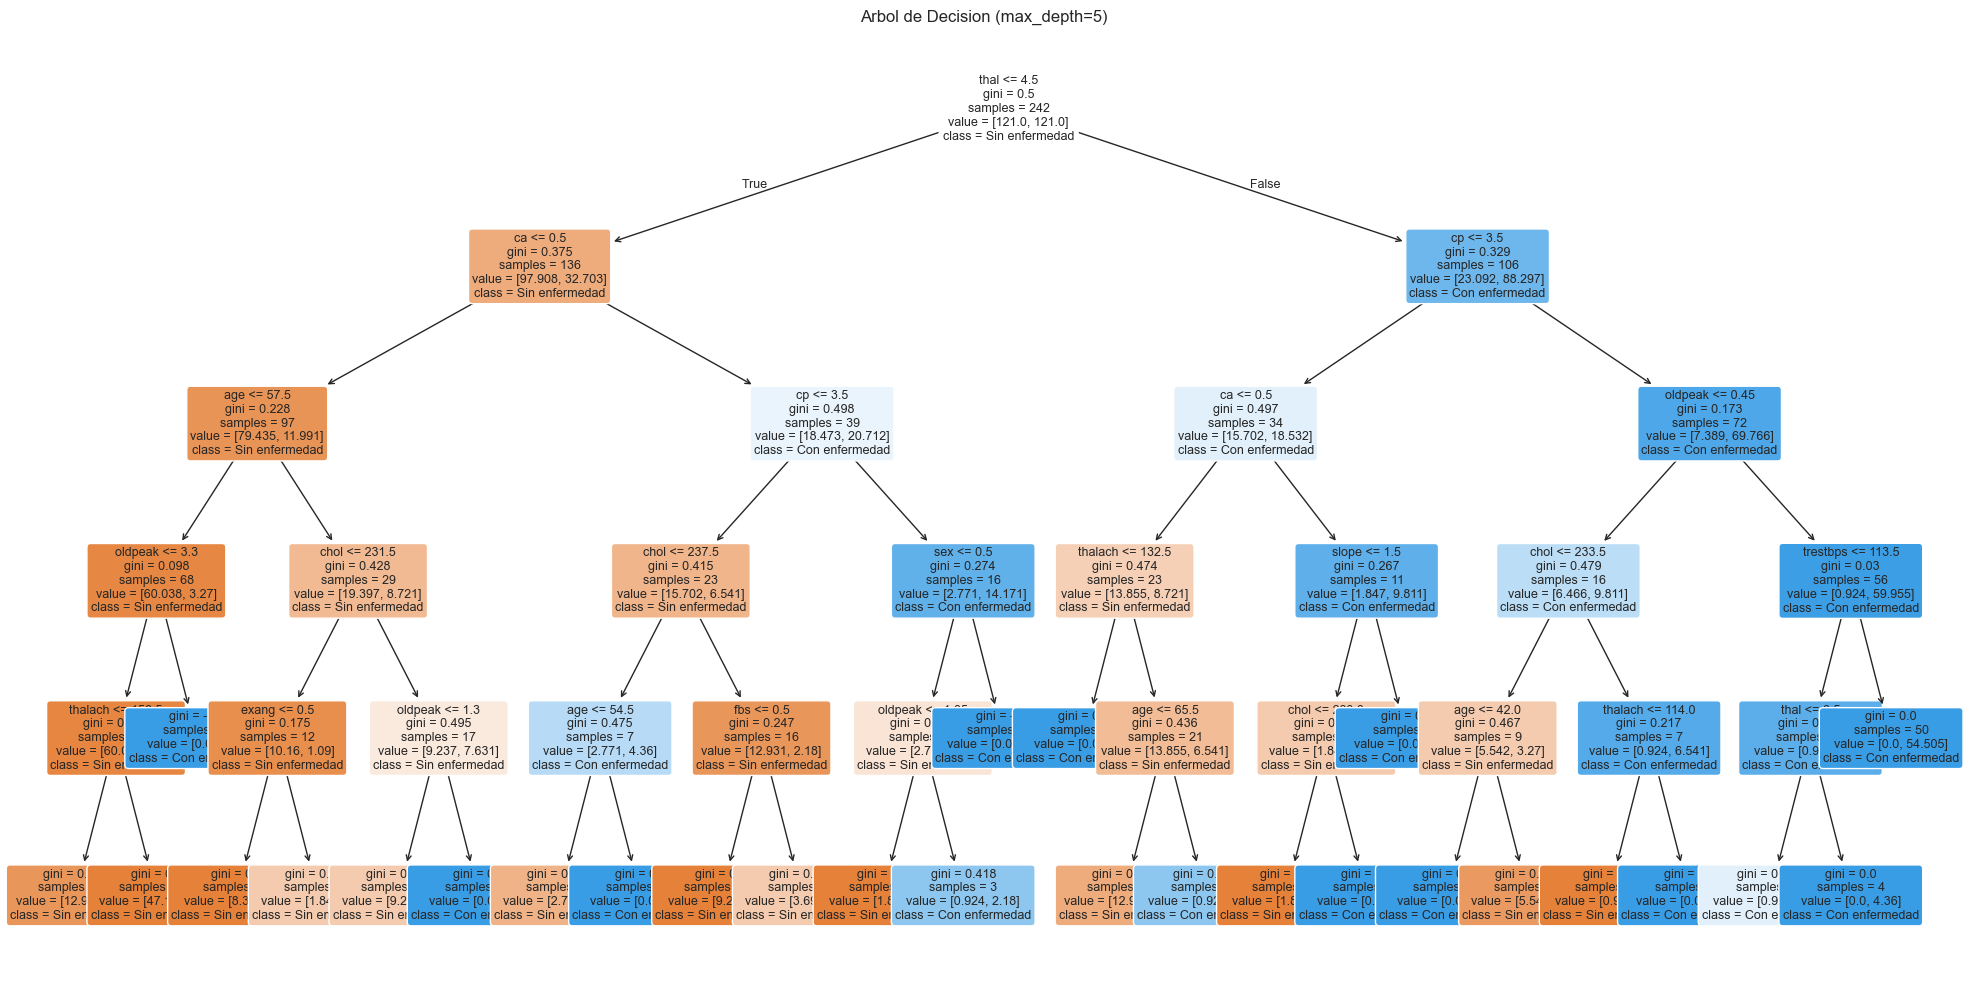

In [16]:
plt.figure(figsize=(20, 10))
plot_tree(tree, feature_names=FEATURES,
          class_names=['Sin enfermedad', 'Con enfermedad'],
          filled=True, rounded=True, fontsize=9)
plt.title('Arbol de Decision (max_depth=5)')
plt.tight_layout()
plt.show()

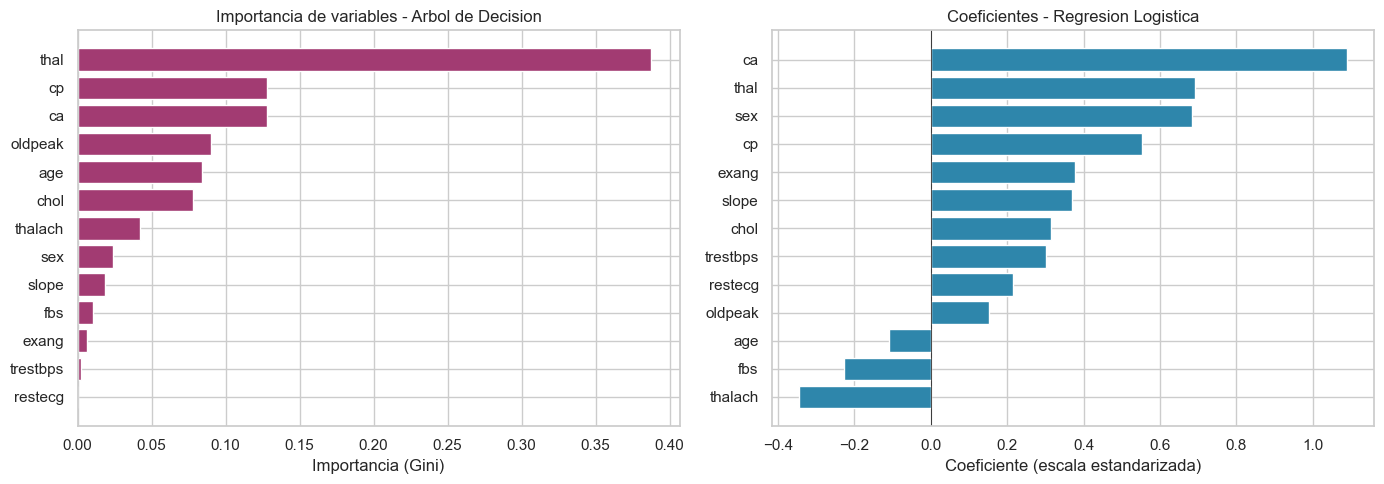

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

imp_tree = pd.Series(tree.feature_importances_, index=FEATURES).sort_values()
axes[0].barh(imp_tree.index, imp_tree.values, color='#A23B72')
axes[0].set_title('Importancia de variables - Arbol de Decision')
axes[0].set_xlabel('Importancia (Gini)')

coef_log = pd.Series(log.coef_[0], index=FEATURES).sort_values()
axes[1].barh(coef_log.index, coef_log.values, color='#2E86AB')
axes[1].axvline(0, color='black', lw=0.5)
axes[1].set_title('Coeficientes - Regresion Logistica')
axes[1].set_xlabel('Coeficiente (escala estandarizada)')

plt.tight_layout()
plt.show()

In [18]:
print('=== REPORTE REGRESION LOGISTICA ===')
print(classification_report(y_test, y_pred_log,
                             target_names=['Sin enfermedad','Con enfermedad']))
print('=== REPORTE ARBOL DE DECISION ===')
print(classification_report(y_test, y_pred_tree,
                             target_names=['Sin enfermedad','Con enfermedad']))

=== REPORTE REGRESION LOGISTICA ===
                precision    recall  f1-score   support

Sin enfermedad       0.93      0.79      0.85        33
Con enfermedad       0.79      0.93      0.85        28

      accuracy                           0.85        61
     macro avg       0.86      0.86      0.85        61
  weighted avg       0.86      0.85      0.85        61

=== REPORTE ARBOL DE DECISION ===
                precision    recall  f1-score   support

Sin enfermedad       0.86      0.76      0.81        33
Con enfermedad       0.75      0.86      0.80        28

      accuracy                           0.80        61
     macro avg       0.81      0.81      0.80        61
  weighted avg       0.81      0.80      0.80        61



## IX. Sintesis de hallazgos

1. **PCA:** 8 componentes principales preservan el 80% de la varianza. El primer componente puede interpretarse como un eje de **severidad cardiaca** (carga sobre oldpeak, exang, thal, ca).
2. **Seleccion de features:** las 5 variables mas correlacionadas con el diagnostico son `thal`, `ca`, `exang`, `oldpeak` y `thalach`, todas relacionadas con sintomas y respuesta al esfuerzo.
3. **Modelamiento:** la **Regresion Logistica supera al Arbol de Decision** en todas las metricas relevantes: accuracy (85% vs 80%), F1 (0.85 vs 0.80) y especialmente ROC-AUC (0.95 vs 0.81). La validacion cruzada confirma el patron y muestra menor varianza para la logistica.
4. **Recomendacion:** la logistica es el modelo de eleccion por desempeno + interpretabilidad (sus coeficientes son odds-ratios) + estabilidad. Para un escenario clinico real con clases desbalanceadas se evaluarian ademas modelos de ensamble (Random Forest, Gradient Boosting).

La reflexion completa, conclusiones y referencias APA estan en el **documento Word adjunto**.